<a href="https://colab.research.google.com/github/smsag99/Thesis/blob/main/codes/WeatherDataDownloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [1]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 691.7/691.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 71.3 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00


## Load Farm Data

In [2]:
datasetFarmPath = '/content/drive/MyDrive/Thesis_Data/latitude and longitude.xlsx'

In [4]:
import pandas as pd

# 1. Define your column names (assuming Excel has headers, these will be used for verification)
col_names = [
    'Farm_name','Commercial_name','Farm_code','ASL_code','Adress','City','Postal_code','Province','Region','Latitude','Longitude'
]

# 2. Read the Excel file into a DataFrame
df_farm = pd.read_excel(datasetFarmPath)

# Check the result
print(df_farm.head())
print(f"\nTotal rows loaded: {len(df_farm)}")

                 Farm name                       Commercial name  Farm_code  \
0  ABBATE MARIA ANTONIETTA               ABBATE MARIA ANTONIETTA    6811505   
1          BOTTAI LEONARDO  AGRIAMBIENTE MUGELLO SOC. COOP. AGR.    4241329   
2          DIANA VALENTINA              AGRICOLA DIANA VALENTINA    6811588   
3         GIULIANI ALVIDIO             AGRICOLA GIULIANI ALVIDIO    5600136   
4              RUBINO VITO    AGRICOLA LA PESCARA DI VITO RUBINO    6812804   

   ASL_code                                 Adress                      City  \
0  084CE077                          VIA NAZIONALE  SANTA MARIA CAPUA VETERE   
1  004FI004                   VIA DI GALLIANO 15/A      BARBERINO DI MUGELLO   
2  027CE147                     P.CO SAN BENEDETTO           CASTEL VOLTURNO   
3  005FR138                    VIA COLLE COTTO. 37                   AMASENO   
4  068CE017  Via Santa Lucia 3 Loc. Pietre Bianche                    RIARDO   

   Postal_code Province    Region   Latitude

In [5]:
farm_loc = df_farm[['Farm_code', 'Latitude', 'Longitude']].copy()
print(farm_loc.head())

   Farm_code   Latitude  Longitude
0    6811505  41.081755  14.266145
1    4241329  44.014669  11.291554
2    6811588  41.057681  13.919402
3    5600136  41.466164  13.330085
4    6812804  41.263069  14.151205


## Download the Data

In [6]:
import os

# Define the output directory name
output_directory = "drive/MyDrive/Thesis_Data/farm_weather_data"

# Create the directory if it doesn't already exist
os.makedirs(output_directory, exist_ok=True)

print(f"Directory '{output_directory}' ensured to exist.")

Directory 'drive/MyDrive/Thesis_Data/farm_weather_data' ensured to exist.


In [ ]:
import openmeteo_requests
import requests_cache
from retry_requests import retry
import pandas as pd
import time
import os

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=3600)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Define the API URL for historical weather data
url = "https://archive-api.open-meteo.com/v1/archive"

# Define the output directory (already created in the previous step)
output_directory = "drive/MyDrive/Thesis_Data/farm_weather_data"

# Define the common date range for all farms
common_start_date = "2013-01-01"
common_end_date = "2025-12-31"

print(f"Fetching hourly weather data for {len(farm_loc)} unique farms...")

for index, row in farm_loc.iterrows():
    farm_code = row['Farm_code']
    latitude = row['Latitude']
    longitude = row['Longitude']

    # Define the output file path
    output_file_path = os.path.join(output_directory, f"farm_{farm_code}_weather.csv")

    # Check if the CSV file already exists for this farm
    if os.path.exists(output_file_path):
        print(f"Skipping Farm Code {farm_code}: CSV file already exists at {output_file_path}")
        continue # Skip to the next farm

    # Parameters for hourly data as per task requirement
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": common_start_date,
        "end_date": common_end_date,
        "hourly": ["temperature_2m", "relative_humidity_2m"], # Hourly data requested
        "timezone": "auto"
    }

    try:
        responses = openmeteo.weather_api(url, params=params)

        # Process first location
        response = responses[0]

        # Process hourly data
        hourly = response.Hourly()
        hourly_data = {
            "time": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
            ),
            "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
            "relative_humidity_2m": hourly.Variables(1).ValuesAsNumpy()
        }


        current_weather_df = pd.DataFrame(hourly_data)

        # Save the DataFrame to a CSV file
        current_weather_df.to_csv(output_file_path, index=False)
        print(f"Successfully fetched and saved data for Farm Code {farm_code} to {output_file_path}")

    except Exception as e:
        print(f"Error fetching data for Farm Code {farm_code} (Lat: {latitude}, Lon: {longitude}): {e}")

    # Add a small delay to avoid hitting rate limits. Increasing from 1s to 5s due to previous API errors.
    time.sleep(0) # Wait for 5 seconds between requests

print("Finished processing all farms.")

### Plotting one of the farms

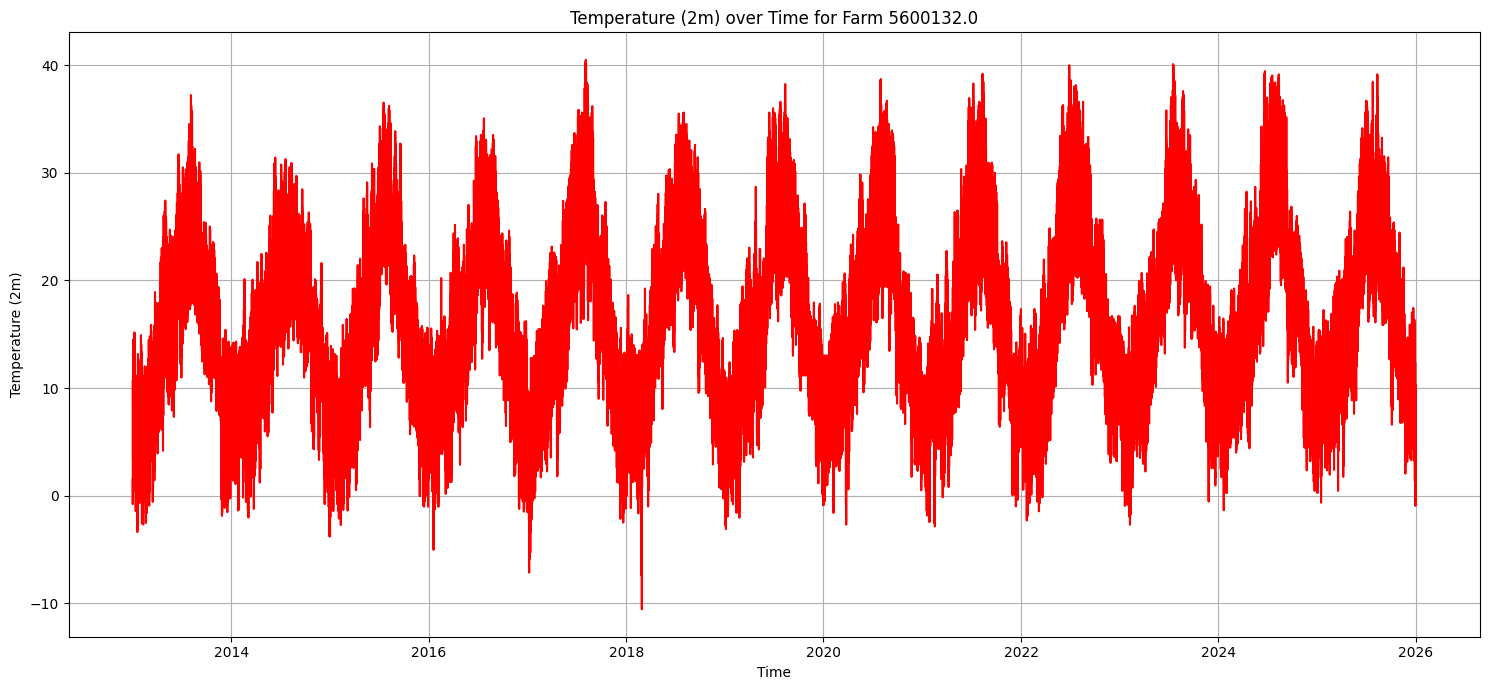

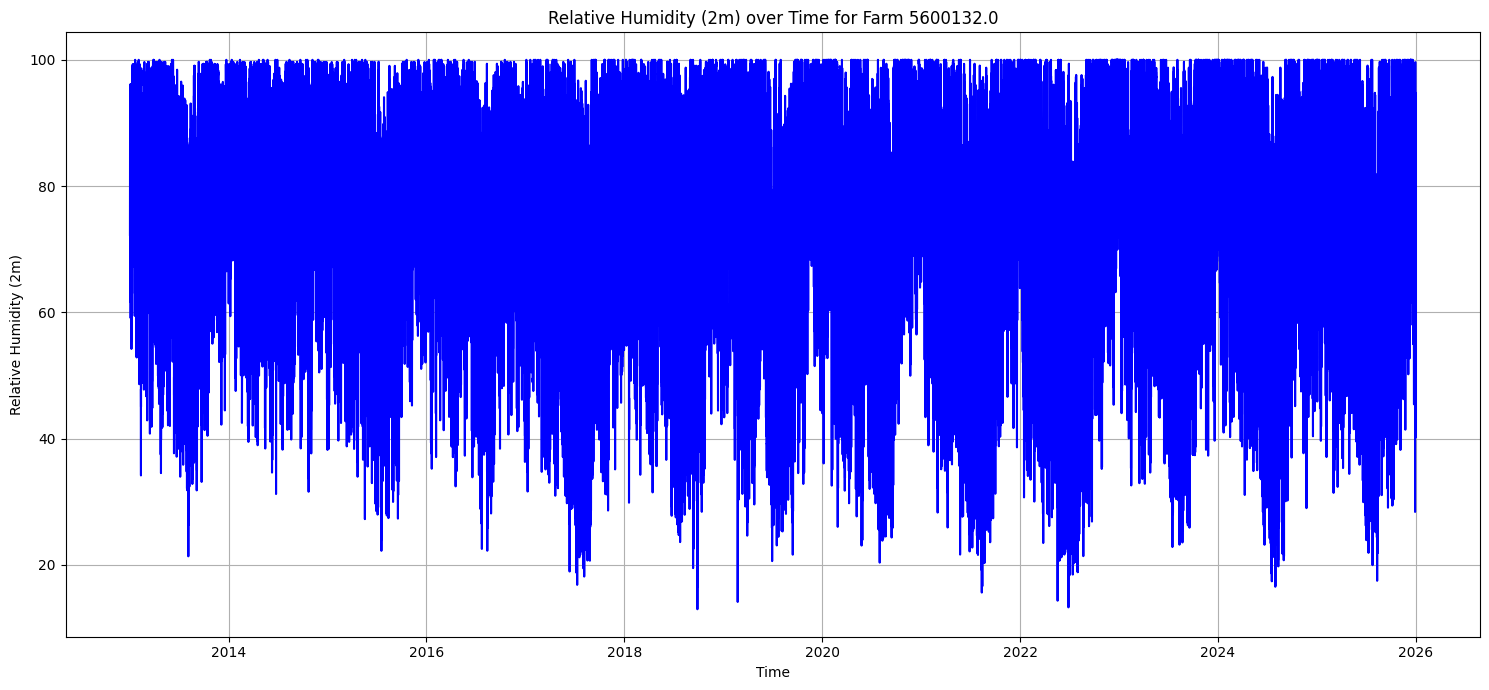

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_farm_weather = pd.read_csv('/content/drive/MyDrive/Thesis_Data/farm_weather_data/farm_5600132.0_weather.csv')

# Ensure 'time' column is in datetime format
df_farm_weather['time'] = pd.to_datetime(df_farm_weather['time'])

# Plot 1: Temperature over time
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_farm_weather, x='time', y='temperature_2m', color='red')
plt.title('Temperature (2m) over Time for Farm 5600132.0')
plt.xlabel('Time')
plt.ylabel('Temperature (2m)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Relative Humidity over time
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_farm_weather, x='time', y='relative_humidity_2m', color='blue')
plt.title('Relative Humidity (2m) over Time for Farm 5600132.0')
plt.xlabel('Time')
plt.ylabel('Relative Humidity (2m)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_farm_weather.head()

,time,temperature_2m,relative_humidity_2m
0,2012-12-31 23:00:00+00:00,1.522,72.280800
1,2013-01-01 00:00:00+00:00,0.822,72.685740
2,2013-01-01 01:00:00+00:00,0.272,75.067030
3,2013-01-01 02:00:00+00:00,-0.178,77.556170
4,2013-01-01 03:00:00+00:00,-0.428,79.868416
